# Phase 6 — Privacy-Preserving Continual Learning: New Methods

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Reference:** Milani, S. — University of Padova

---

## Overview

This notebook explores three new directions for privacy-preserving continual learning,
building on the methods from previous phases.

### 1 — KD-CL + CDML (Combined method)

Phase 5 showed that **KD-CL** (knowledge distillation regularisation) mitigates
catastrophic forgetting but does not protect against MIA. Phase 3 showed that
**CDML** scrambles the feature space to defeat MIA but relies on task-specific seeds.

The idea here is to **stack both mechanisms**:

```
L_total = L_CE(y, g(sₖ ⊙ h))  ← CDML scrambles the embedding before classification
        + λ · distillation_loss(f_new, f_old, buffer)  ← KD anchors old tasks
```

Expected outcome: CDML handles MIA (AUC → 50%); KD handles forgetting (higher
off-diagonal accuracy). Neither mechanism interferes with the other because the
distillation loss is computed in **logit space** (after the CDML layer), so the
old model is also scrambled when computing the reference logits.

### 2 — DP-SGD (Differential Privacy baseline)

**Differential Privacy via DP-SGD** (Abadi et al. 2016) adds calibrated Gaussian
noise to per-sample gradients during training. It provides a **formal mathematical
privacy guarantee** expressed as (ε, δ)-DP, where smaller ε = stronger privacy.

Key idea:
```
gradient_privatised = clip(∇L, C) + N(0, σ²C²I)   per sample
```
Clipping bound `C` limits per-sample sensitivity; noise σ calibrated to the
privacy budget. This is the gold standard formal baseline for MIA defence.

Unlike CDML, DP-SGD does **not** require sharing a secret key — the privacy
guarantee holds for any observer. However it has a well-known **accuracy cost**
that typically grows with the number of classes (118 here).

### 3 — Entropy Regularisation (HAMP-style)

MIA attacks exploit the model's **overconfidence** on training samples: members
have softmax probability ≈ 1.0 while non-members have ≈ 0.5–0.9, and the attacker
thresholds on this gap (LiRA).

**HAMP** (Ye et al. NDSS 2024) explicitly penalises overconfidence by adding a
**maximum-entropy regularisation** term to the loss:

```
L_total = L_CE(y, f(x)) + α · H_target - H(f(x))
        = L_CE + α · max(0, H_target - H(softmax(logits)))
```

where `H(p) = -Σ pᵢ log pᵢ` is the Shannon entropy of the output distribution.
When entropy is below a target `H_target`, the penalty pushes the model to be
less confident — narrowing the member/non-member confidence gap the attacker relies on.

This mechanism is **orthogonal to CDML**: CDML scrambles the feature geometry;
entropy regularisation flattens the output distribution. Both reduce MIA AUC
through different mechanisms, and their combination is a natural experiment.

---

## Summary table

| Method | Forgetting mitigation | MIA mitigation | Overhead |
|---|---|---|---|
| **Std** | ✗ | ✗ | None |
| **CDML** (Phase 3 baseline) | ✓ (feature orthogonality) | ✓ (key required) | 4 bytes/task |
| **KD-CL + CDML** (new) | ✓✓ (distillation + CDML) | ✓ (key required) | 4 bytes + buffer |
| **DP-SGD** (new) | ✗ / marginal | ✓ (formal ε-DP) | Accuracy penalty |
| **Entropy Reg** (new) | ✗ / marginal | ✓ (confidence flattening) | One α hyperparameter |
| **CDML + Entropy Reg** (new) | ✓ | ✓✓ (dual mechanism) | 4 bytes + α |


## 0. Imports and device setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    DataLoader, TensorDataset, random_split, ConcatDataset, Subset
)
from sklearn.metrics import roc_curve, auc
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

# Try to import opacus for DP-SGD; graceful fallback to manual implementation
try:
    from opacus import PrivacyEngine
    from opacus.validators import ModuleValidator
    OPACUS_AVAILABLE = True
    print('Opacus found — using PrivacyEngine for DP-SGD')
except ImportError:
    OPACUS_AVAILABLE = False
    print('Opacus not found — using manual DP-SGD implementation')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Opacus not found — using manual DP-SGD implementation
Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

In [2]:
TRAIN_DATA_DIR = '../Data/Dataset_1/train'
TEST_DATA_DIR  = '../Data/Dataset_1/test'

N_CHANNELS      = 6
WINDOW_SIZE     = 128
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27
BATCH_SIZE      = 64
EMBED_DIM       = 128
N_CLASSES_TOTAL = 118
CDML_SEED_BASE  = 1000

EPOCHS   = 50    # 400 to fully reproduce paper; 50 for fast iteration
LR_INIT  = 1e-3
LR_DECAY = 0.98

TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}

# ── Method-specific hyperparameters ──────────────────────────────────────────

# KD-CL + CDML
KD_LAMBDA          = 0.001   # distillation strength
KD_ALPHA           = 0.0     # base weight (0 = focal only)
KD_BETA            = 1.0     # extra weight when old model was correct
MEMORY_FRACTION    = 0.20    # fraction of past task kept in buffer

# DP-SGD
DP_NOISE_MULTIPLIER = 1.1    # σ in the DP noise formula
DP_MAX_GRAD_NORM    = 1.0    # gradient clipping bound C
# Privacy budget is tracked across tasks (composition)
# ε ≈ noise_multiplier ↑ → ε ↓ (more private, less accurate)

# Entropy Regularisation (HAMP-style)
ENT_ALPHA      = 0.3     # weight of the entropy penalty
ENT_H_TARGET   = None    # if None: use log(n_classes)/2 as target
                         # i.e. push entropy towards half of maximum

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

Configuration set.


## 2. Data loading — identical to all previous phases

In [3]:
def load_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y

X_train, y_train = load_split(TRAIN_DATA_DIR, 'train')
X_test,  y_test  = load_split(TEST_DATA_DIR,  'test')

ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])

def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t = torch.tensor(X_tr[mask_tr])
        y_t = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(torch.tensor(X_te[mask_te]),
                                torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds)} train | {n_val} val | {len(test_ds)} test')
    return task_data

task_data  = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED
)
task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
print(f'\nTrain: {X_train.shape}  Test: {X_test.shape}')

Task 1: 7347 train | 1296 val | 975 test
Task 2: 7241 train | 1277 val | 962 test
Task 3: 6540 train | 1153 val | 871 test
Task 4: 7013 train | 1237 val | 932 test

Train: (33104, 6, 128)  Test: (3740, 6, 128)


## 3. Model definitions

All methods share the same `GaitCNN` backbone from previous phases.
- `GaitCNN_CDML`      — backbone + CDML (from Phase 3)
- `GaitCNN_CDML_KD`   — backbone + CDML + memory buffer for distillation loss
- `GaitCNN` used with DP-SGD / entropy reg (no architectural change needed)

In [4]:
# ── Backbone (identical to all previous phases) ───────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size//2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)

class GaitCNN(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)
    def embed(self, x): return self.embedding(self.feature_extractor(x))
    def forward(self, x): return self.classifier(self.embed(x))

# ── CDML helpers (from Phase 3) ────────────────────────────────────────────────
def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    return torch.tensor(np.where(rng.random(embed_dim) >= 0.5, 1.0, -1.0).astype(np.float32))

class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h): return h * self.sequence

class GaitCNN_CDML(nn.Module):
    """CDML model — used as the standalone CDML baseline in this notebook."""
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds     = {}
    def forward(self, x):
        return self.backbone.classifier(self.cdml(self.backbone.embed(x)))
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)

print('Models defined.')
_ = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)
print(f'GaitCNN params: {sum(p.numel() for p in _.parameters()):,}')
del _

Models defined.
GaitCNN params: 227,222


## 4. Shared utilities

In [5]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        correct += (model(X_b).argmax(1) == y_b).sum().item()
        total   += len(y_b)
    return correct / total


@torch.no_grad()
def get_logit_scores(model, dataset, device, batch_size=256):
    """LiRA attack score: logit of the correct-class softmax probability."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    scores = []
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        probs = torch.softmax(model(X_b), dim=1)
        p_correct = probs[torch.arange(len(y_b)), y_b].clamp(1e-7, 1 - 1e-7)
        scores.append(torch.log(p_correct / (1 - p_correct)).cpu().numpy())
    return np.concatenate(scores)


def compute_roc_metrics(member_scores, nonmember_scores):
    scores = np.concatenate([member_scores, nonmember_scores])
    labels = np.concatenate([np.ones(len(member_scores)), np.zeros(len(nonmember_scores))])
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer = float(np.mean([fpr[eer_idx], fnr[eer_idx]]))
    return fpr, tpr, roc_auc, eer


def mia_on_snapshot(snap, task_data, task_names, device, cdml_seeds=None):
    """
    Run LiRA on a single model snapshot, evaluating every seen task.
    cdml_seeds: dict {task_name: seed} — supply if snap has a CDML layer.
    Returns AUC and EER matrices (n_tasks × n_tasks).
    """
    n = len(task_names)
    auc_mat = np.full((n, n), np.nan)
    eer_mat = np.full((n, n), np.nan)

    for step_idx in range(n):
        for eval_idx in range(step_idx + 1):
            eval_task = task_names[eval_idx]

            # Apply correct CDML sequence if applicable
            if cdml_seeds and eval_task in cdml_seeds:
                snap.set_task_sequence(eval_task, cdml_seeds[eval_task])

            m_s  = get_logit_scores(snap, task_data[eval_task]['train'], device)
            nm_s = get_logit_scores(snap, task_data[eval_task]['test'],  device)
            _, _, ra, er = compute_roc_metrics(m_s, nm_s)
            auc_mat[step_idx, eval_idx] = ra * 100
            eer_mat[step_idx, eval_idx] = er * 100

    return auc_mat, eer_mat


def print_mia_table(auc_mat, eer_mat, method_name):
    n = auc_mat.shape[0]
    print(f'\n── {method_name} — AUC(%) / EER(%) ──')
    header = '  ' + ''.join([f'  Task{j+1:>3}' for j in range(n)])
    print(header)
    for i in range(n):
        row = f'After T{i+1}  '
        for j in range(n):
            if np.isnan(auc_mat[i, j]):
                row += '   —    '
            else:
                row += f' {auc_mat[i,j]:.1f}/{eer_mat[i,j]:.1f}'
        print(row)

print('Utilities defined.')

Utilities defined.


---
## Method 1 — CDML (baseline, re-run for direct comparison)

Re-running CDML from Phase 3 here so all methods are trained under identical
conditions (same EPOCHS, same seed) for a fair comparison.

In [6]:
def run_cdml(task_data, task_names, device,
             epochs, lr_init, lr_decay, batch_size, verbose_every=20):
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM,
                               seed=CDML_SEED_BASE).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    criterion  = nn.CrossEntropyLoss()

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[CDML] Step {step_idx+1}: {task_name}')
        model.set_task_sequence(task_name, CDML_SEED_BASE + step_idx)

        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)

        for epoch in range(1, epochs + 1):
            model.train()
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                criterion(model(X_b), y_b).backward()
                optimizer.step()
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                val_loader = DataLoader(task_data[task_name]['val'],
                                        batch_size=batch_size, shuffle=False)
                val_acc = evaluate(model, val_loader, device)
                print(f'  Epoch {epoch:>3}/{epochs}  val={val_acc:.3f}')

        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            model.set_task_sequence(eval_task, model.seeds[eval_task])
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc = evaluate(model, test_loader, device)
            acc_matrix[step_idx, eval_idx] = acc
            print(f'  {eval_task}: {acc*100:.1f}%')

    return model, acc_matrix


print('\n' + '='*55)
print('Method 1: CDML (baseline, re-run)')
print('='*55)
torch.manual_seed(RANDOM_SEED)
model_cdml, acc_cdml = run_cdml(
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE
)


Method 1: CDML (baseline, re-run)

[CDML] Step 1: Task 1
  Epoch   1/50  val=0.941
  Epoch  20/50  val=0.991
  Epoch  40/50  val=0.990
  Task 1: 89.7%

[CDML] Step 2: Task 2
  Epoch   1/50  val=0.956
  Epoch  20/50  val=0.987
  Epoch  40/50  val=0.989
  Task 1: 79.1%
  Task 2: 93.9%

[CDML] Step 3: Task 3
  Epoch   1/50  val=0.953
  Epoch  20/50  val=0.979
  Epoch  40/50  val=0.984
  Task 1: 54.6%
  Task 2: 72.9%
  Task 3: 93.0%

[CDML] Step 4: Task 4
  Epoch   1/50  val=0.965
  Epoch  20/50  val=0.986
  Epoch  40/50  val=0.989
  Task 1: 43.9%
  Task 2: 68.3%
  Task 3: 75.1%
  Task 4: 98.3%


---
## Method 2 — KD-CL + CDML (combined)

We combine Phase 5's knowledge distillation regularisation with Phase 3's CDML
feature scrambling into a single training loop.

### Why this combination makes sense

- **CDML** scrambles the feature space with a task-specific binary sequence,
  making MIA fail (attacker cannot read confidence from scrambled logits without the key).
- **KD distillation** anchors the model to its previous-task outputs via a memory
  buffer, preventing catastrophic forgetting.
- The two mechanisms operate in different spaces: CDML in the **embedding domain**,
  KD in the **logit domain** (after the classifier). There is no architectural conflict.
- The key question is whether the distillation loss computed across different CDML
  sequences (each task uses a different `sₖ`) is still meaningful. Since both `f_new`
  and `f_old` process the buffer with their respective tasks' sequences, the distillation
  term still captures divergence in the classifier's decision boundary.

### Implementation note

When computing the KD term on buffer samples from task `j`, we load the sequence
`s_j` into both the current model and the old snapshot. This ensures the reference
logits `f_old(x)` and the new logits `f_new(x)` are computed in the same feature
space — making the L2 distillation term geometrically meaningful.

In [8]:
# ── Focal distillation loss (from Phase 5) ────────────────────────────────────
def focal_distillation_loss(logits_new, logits_old, y_true, alpha, beta):
    """
    PCT/RCAT focal distillation:
        L = mean( (α + β·I[ŷ_old=y]) · ‖logits_new - logits_old‖² )
    """
    l2_dist    = ((logits_new - logits_old) ** 2).sum(dim=1)
    old_correct = (logits_old.argmax(dim=1) == y_true).float()
    weight     = alpha + beta * old_correct
    return (weight * l2_dist).mean()


# ── Memory buffer (from Phase 5) ──────────────────────────────────────────────
class MemoryBuffer:
    def __init__(self, fraction, seed=RANDOM_SEED):
        self.fraction = fraction
        self.rng      = np.random.default_rng(seed)
        self._data    = []   # list of (TensorDataset, task_name)

    def add_task(self, train_dataset, task_name):
        n = len(train_dataset)
        k = max(1, int(n * self.fraction))
        idx = self.rng.choice(n, size=k, replace=False).tolist()
        Xs, ys = zip(*[train_dataset[i] for i in idx])
        ds = TensorDataset(torch.stack(Xs), torch.stack(ys))
        self._data.append((ds, task_name))
        print(f'  Buffer: +{k} samples from {task_name}  '
              f'(total: {sum(len(d) for d, _ in self._data)})')

    def get_items(self):
        """Return list of (TensorDataset, task_name) for all past tasks."""
        return self._data

    def __len__(self):
        return sum(len(d) for d, _ in self._data)


def run_cdml_kd(task_data, task_names, device,
                epochs, lr_init, lr_decay, batch_size,
                kd_lambda, kd_alpha, kd_beta, memory_fraction,
                verbose_every=20):
    """
    KD-CL + CDML combined training loop.

    At each step k:
      1. Switch CDML sequence to sₖ
      2. Train on task k data with L_CE (as in standard CDML)
      3. For each past task j in the memory buffer:
         a. Load sequence s_j into both current model and frozen old model
         b. Compute focal distillation loss between their logits
         c. Add λ · distillation loss to the gradient
      4. After step k: snapshot old model, add task k data to buffer
    """
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM,
                               seed=CDML_SEED_BASE).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    buffer     = MemoryBuffer(fraction=memory_fraction)
    old_model  = None
    criterion  = nn.CrossEntropyLoss()

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[CDML+KD] Step {step_idx+1}: {task_name}')
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)

        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)

        for epoch in range(1, epochs + 1):
            model.train()
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()

                # ── Task loss (current task, current sequence) ─────────────
                model.set_task_sequence(task_name, seed_k)
                loss = criterion(model(X_b), y_b)

                # ── Distillation loss (past tasks from buffer) ─────────────
                if old_model is not None and len(buffer) > 0:
                    kd_loss_total = torch.tensor(0.0, device=device)
                    for past_ds, past_task in buffer.get_items():
                        past_seed = model.seeds.get(past_task, CDML_SEED_BASE)
                        # Sample a random mini-batch from the buffer
                        n_buf = len(past_ds)
                        idx_buf = torch.randperm(n_buf)[:batch_size].tolist()
                        X_buf = torch.stack([past_ds[i][0] for i in idx_buf]).to(device)
                        y_buf = torch.stack([past_ds[i][1] for i in idx_buf]).to(device)

                        # Both model and old_model use the past task's sequence
                        model.set_task_sequence(past_task, past_seed)
                        old_model.set_task_sequence(past_task, past_seed)

                        logits_new = model(X_buf)
                        with torch.no_grad():
                            logits_old = old_model(X_buf)

                        kd_loss_total = kd_loss_total + focal_distillation_loss(
                            logits_new, logits_old, y_buf, kd_alpha, kd_beta
                        )

                    # Restore current task's sequence for next gradient step
                    model.set_task_sequence(task_name, seed_k)
                    loss = loss + kd_lambda * kd_loss_total

                loss.backward()
                optimizer.step()

            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                val_loader = DataLoader(task_data[task_name]['val'],
                                        batch_size=batch_size, shuffle=False)
                val_acc = evaluate(model, val_loader, device)
                print(f'  Epoch {epoch:>3}/{epochs}  val={val_acc:.3f}')

        # ── After task k: evaluate, snapshot, and update buffer ────────────
        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            model.set_task_sequence(eval_task, model.seeds[eval_task])
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc = evaluate(model, test_loader, device)
            acc_matrix[step_idx, eval_idx] = acc
            print(f'  {eval_task}: {acc*100:.1f}%')

        old_model = deepcopy(model)
        old_model.eval()
        buffer.add_task(task_data[task_name]['train'], task_name)

    return model, acc_matrix


print('\n' + '='*55)
print('Method 2: CDML + KD-CL (combined)')
print('='*55)
torch.manual_seed(RANDOM_SEED)
model_cdml_kd, acc_cdml_kd = run_cdml_kd(
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
    kd_lambda=KD_LAMBDA, kd_alpha=KD_ALPHA, kd_beta=KD_BETA,
    memory_fraction=MEMORY_FRACTION
)


Method 2: CDML + KD-CL (combined)

[CDML+KD] Step 1: Task 1
  Epoch   1/50  val=0.941
  Epoch  20/50  val=0.991
  Epoch  40/50  val=0.990
  Task 1: 89.7%
  Buffer: +1469 samples from Task 1  (total: 1469)

[CDML+KD] Step 2: Task 2
  Epoch   1/50  val=0.957
  Epoch  20/50  val=0.980
  Epoch  40/50  val=0.982
  Task 1: 89.9%
  Task 2: 95.4%
  Buffer: +1448 samples from Task 2  (total: 2917)

[CDML+KD] Step 3: Task 3
  Epoch   1/50  val=0.955
  Epoch  20/50  val=0.977
  Epoch  40/50  val=0.977
  Task 1: 89.9%
  Task 2: 95.3%
  Task 3: 91.5%
  Buffer: +1308 samples from Task 3  (total: 4225)

[CDML+KD] Step 4: Task 4
  Epoch   1/50  val=0.969
  Epoch  20/50  val=0.988
  Epoch  40/50  val=0.987
  Task 1: 90.1%
  Task 2: 95.5%
  Task 3: 91.2%
  Task 4: 97.2%
  Buffer: +1402 samples from Task 4  (total: 5627)


---
## Method 3 — DP-SGD

### Background

DP-SGD (Abadi et al. 2016) adds calibrated Gaussian noise to the sum of per-sample
gradients at each training step. Formally it guarantees:

```
Pr[M(D) ∈ S] ≤ exp(ε) · Pr[M(D') ∈ S] + δ
```

for any two neighbouring datasets D, D' differing by one sample. This means: any
individual training sample cannot change the model's output distribution by more
than a factor of `exp(ε)`. This directly bounds MIA success probability.

### DP-SGD algorithm

For each mini-batch, instead of the standard gradient update:
1. **Compute per-sample gradients** `gᵢ = ∇Lᵢ` for each sample i in the batch
2. **Clip each gradient** to L2 norm ≤ C: `g̃ᵢ = gᵢ / max(1, ‖gᵢ‖/C)`
3. **Add Gaussian noise**: `g_noisy = (1/B) · [Σ g̃ᵢ + N(0, σ²C²I)]`
4. **Update** using the noisy gradient

The privacy accountant tracks (ε, δ) across all epochs and all tasks via the
**moments accountant** (or RDP/f-DP).

### Continual learning + DP-SGD

Privacy composition across tasks is the key concern. If we run T tasks each with
privacy budget (εₜ, δ), the total budget is at most `Σ εₜ` (basic composition),
though tighter composition theorems (RDP, moments accountant) give much better bounds.
The key insight: **DP-SGD provides per-task privacy but the total budget grows**.
This is a fundamental limitation vs CDML which requires only 4 bytes per task.

In [9]:
# ── Manual DP-SGD implementation ──────────────────────────────────────────────
# We implement DP-SGD manually using per-sample gradient computation.
# This is equivalent to Opacus but works without the extra dependency.
# For production use, Opacus is recommended (it handles edge cases better).

def dp_sgd_step(model, X_batch, y_batch, optimizer, criterion,
                max_grad_norm, noise_multiplier, device):
    """
    One DP-SGD gradient step on a batch.

    Algorithm:
      1. Compute per-sample gradients via individual backward passes
      2. Clip each gradient to L2 norm ≤ max_grad_norm
      3. Sum clipped gradients, add Gaussian noise scaled by (noise_multiplier * max_grad_norm)
      4. Divide by batch size → noisy average gradient
      5. Apply to model weights

    Note: This is a simple implementation that computes full backward passes per sample.
    Opacus uses the grad_sample hook for efficiency.
    """
    B = len(X_batch)
    optimizer.zero_grad()

    # Accumulate clipped per-sample gradients
    cumulative_grads = [torch.zeros_like(p) for p in model.parameters()]

    for i in range(B):
        # Single-sample forward + backward
        xi = X_batch[i:i+1].to(device)
        yi = y_batch[i:i+1].to(device)

        loss_i = criterion(model(xi), yi)
        grads_i = torch.autograd.grad(loss_i, model.parameters(),
                                       retain_graph=False, create_graph=False)

        # L2 norm of all parameter gradients concatenated
        total_norm = torch.sqrt(sum(g.norm()**2 for g in grads_i))

        # Clip: scale down if norm exceeds C
        clip_factor = max_grad_norm / max(total_norm.item(), max_grad_norm)
        for cumg, gi in zip(cumulative_grads, grads_i):
            cumg += gi * clip_factor

    # Add Gaussian noise, divide by batch size
    noise_scale = noise_multiplier * max_grad_norm
    for p, cumg in zip(model.parameters(), cumulative_grads):
        noisy_grad = (cumg + torch.randn_like(cumg) * noise_scale) / B
        p.grad = noisy_grad

    # Compute approximate batch loss for logging (no grad)
    with torch.no_grad():
        batch_loss = criterion(model(X_batch.to(device)), y_batch.to(device)).item()

    optimizer.step()
    return batch_loss


def run_dp_sgd(task_data, task_names, device,
               epochs, lr_init, lr_decay, batch_size,
               noise_multiplier, max_grad_norm,
               verbose_every=20):
    """
    Standard fine-tuning with DP-SGD (no replay, no special architecture).
    Privacy is guaranteed per-task; total budget grows with number of tasks.
    """
    model      = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    criterion  = nn.CrossEntropyLoss()

    total_epsilon = 0.0   # rough tracking (basic composition, for illustration)

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[DP-SGD] Step {step_idx+1}: {task_name}')

        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)

        # Rough privacy budget per task using Gaussian mechanism approximation:
        # ε ≈ sqrt(2 * epochs * log(1/δ)) / noise_multiplier  (simplified)
        # Use δ = 1/n as rule of thumb
        n_train  = len(task_data[task_name]['train'])
        delta    = 1.0 / n_train
        eps_task = (epochs * np.log(1/delta))**0.5 / noise_multiplier  # very rough
        total_epsilon += eps_task
        print(f'  Rough ε per task ≈ {eps_task:.2f}  |  cumulative ε ≈ {total_epsilon:.2f}')

        for epoch in range(1, epochs + 1):
            model.train()
            epoch_loss = 0.0
            n_batches  = 0
            for X_b, y_b in loader:
                batch_loss = dp_sgd_step(
                    model, X_b, y_b, optimizer, criterion,
                    max_grad_norm, noise_multiplier, device
                )
                epoch_loss += batch_loss
                n_batches  += 1
            scheduler.step()

            if epoch % verbose_every == 0 or epoch == 1:
                val_loader = DataLoader(task_data[task_name]['val'],
                                        batch_size=batch_size, shuffle=False)
                val_acc = evaluate(model, val_loader, device)
                print(f'  Epoch {epoch:>3}/{epochs}  '
                      f'avg_loss={epoch_loss/n_batches:.4f}  val={val_acc:.3f}')

        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc = evaluate(model, test_loader, device)
            acc_matrix[step_idx, eval_idx] = acc
            print(f'  {eval_task}: {acc*100:.1f}%')

    print(f'\n  Final cumulative ε ≈ {total_epsilon:.2f}  (basic composition bound)')
    return model, acc_matrix


print('\n' + '='*55)
print('Method 3: DP-SGD')
print('='*55)
# NOTE: DP-SGD with per-sample gradients is slow (~B× slower per epoch than standard).
# Reduce EPOCHS here if time is constrained.
DP_EPOCHS = max(5, EPOCHS // 5)   # use fewer epochs for DP-SGD to save time
print(f'Running DP-SGD for {DP_EPOCHS} epochs (reduced for speed)')
torch.manual_seed(RANDOM_SEED)
model_dp, acc_dp = run_dp_sgd(
    task_data, task_names, DEVICE,
    DP_EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
    noise_multiplier=DP_NOISE_MULTIPLIER,
    max_grad_norm=DP_MAX_GRAD_NORM
)


Method 3: DP-SGD
Running DP-SGD for 10 epochs (reduced for speed)

[DP-SGD] Step 1: Task 1
  Rough ε per task ≈ 8.58  |  cumulative ε ≈ 8.58
  Epoch   1/10  avg_loss=4.4761  val=0.048
  Task 1: 26.1%

[DP-SGD] Step 2: Task 2
  Rough ε per task ≈ 8.57  |  cumulative ε ≈ 17.15
  Epoch   1/10  avg_loss=5.4664  val=0.076
  Task 1: 0.0%
  Task 2: 29.9%

[DP-SGD] Step 3: Task 3
  Rough ε per task ≈ 8.52  |  cumulative ε ≈ 25.67
  Epoch   1/10  avg_loss=5.5836  val=0.154
  Task 1: 0.0%
  Task 2: 0.0%
  Task 3: 60.6%

[DP-SGD] Step 4: Task 4
  Rough ε per task ≈ 8.55  |  cumulative ε ≈ 34.22
  Epoch   1/10  avg_loss=5.2524  val=0.256
  Task 1: 0.0%
  Task 2: 0.0%
  Task 3: 0.0%
  Task 4: 74.5%

  Final cumulative ε ≈ 34.22  (basic composition bound)


---
## Method 4 — Entropy Regularisation (HAMP-style)

### Background

LiRA and similar MIA attacks exploit the model's **overconfident predictions** on
training samples. The insight from **HAMP** (Ye et al., NDSS 2024) is:

> *All MIA variants ultimately reduce to detecting that the model is more confident
> on members than on non-members. If we force the model to be uniformly less confident,
> the attack has no signal to exploit.*

The defence adds an **entropy penalty** to the cross-entropy loss:

```
L_total = L_CE(y, f(x)) + α · max(0, H_target - H(softmax(f(x))))
```

where `H(p) = -Σ pᵢ log pᵢ` is Shannon entropy.

- When `H(output) < H_target`, the penalty is active → pushes the model to be
  less confident (spread probability mass more evenly).
- When `H(output) ≥ H_target`, penalty is zero → does not over-regularise.
- `H_target = log(C)/2` (half the maximum entropy) is a sensible default for C classes.

### Key difference from CDML

CDML defeats MIA by **making the attacker's query incoherent** (without the key,
the confidence scores are meaningless). Entropy regularisation defeats MIA by
**making confidence scores uniformly low** for everyone — no key needed, but the
model is genuinely less discriminative.

### Extension: CDML + Entropy Regularisation

We also test stacking entropy regularisation on top of CDML. The hypothesis is
that this dual mechanism provides the strongest protection:
- CDML: attacker without key gets random-looking scores regardless of membership
- Entropy reg: even with the key, the confidence gap is suppressed

In [10]:
import math

# Default entropy target: half of maximum entropy
H_MAX    = math.log(N_CLASSES_TOTAL)          # log(118) ≈ 4.77 nats
H_TARGET = ENT_H_TARGET if ENT_H_TARGET else H_MAX / 2.0
print(f'Entropy target H_target = {H_TARGET:.3f}  '
      f'(H_max = {H_MAX:.3f})')


def entropy_reg_loss(logits, alpha, h_target):
    """
    Entropy regularisation penalty: penalises batches where mean entropy
    is below the target.

    L_ent = α · max(0, H_target - mean_H(batch))

    Parameters
    ----------
    logits   : (B, C)
    alpha    : float — weight of the entropy penalty
    h_target : float — target entropy (nats)
    """
    probs   = torch.softmax(logits, dim=1)
    # Per-sample entropy: H(p) = -sum(p * log(p + eps))
    entropy = -(probs * torch.log(probs + 1e-12)).sum(dim=1)  # (B,)
    mean_H  = entropy.mean()
    penalty = torch.clamp(h_target - mean_H, min=0.0)
    return alpha * penalty


def run_entropy_reg(task_data, task_names, device,
                    epochs, lr_init, lr_decay, batch_size,
                    ent_alpha, h_target,
                    verbose_every=20):
    """Standard fine-tuning + entropy regularisation (no CDML, no replay)."""
    model      = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    criterion  = nn.CrossEntropyLoss()

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[EntReg] Step {step_idx+1}: {task_name}')
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)

        for epoch in range(1, epochs + 1):
            model.train()
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                logits = model(X_b)
                loss   = criterion(logits, y_b) + entropy_reg_loss(logits, ent_alpha, h_target)
                loss.backward()
                optimizer.step()
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                val_loader = DataLoader(task_data[task_name]['val'],
                                        batch_size=batch_size, shuffle=False)
                val_acc = evaluate(model, val_loader, device)
                print(f'  Epoch {epoch:>3}/{epochs}  val={val_acc:.3f}')

        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc = evaluate(model, test_loader, device)
            acc_matrix[step_idx, eval_idx] = acc
            print(f'  {eval_task}: {acc*100:.1f}%')

    return model, acc_matrix


def run_cdml_entropy(task_data, task_names, device,
                     epochs, lr_init, lr_decay, batch_size,
                     ent_alpha, h_target,
                     verbose_every=20):
    """CDML + entropy regularisation (dual privacy mechanism, no replay)."""
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM,
                               seed=CDML_SEED_BASE).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    criterion  = nn.CrossEntropyLoss()

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[CDML+Ent] Step {step_idx+1}: {task_name}')
        model.set_task_sequence(task_name, CDML_SEED_BASE + step_idx)

        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)

        for epoch in range(1, epochs + 1):
            model.train()
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                logits = model(X_b)
                loss   = (criterion(logits, y_b)
                          + entropy_reg_loss(logits, ent_alpha, h_target))
                loss.backward()
                optimizer.step()
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, CDML_SEED_BASE + step_idx)
                val_loader = DataLoader(task_data[task_name]['val'],
                                        batch_size=batch_size, shuffle=False)
                val_acc = evaluate(model, val_loader, device)
                print(f'  Epoch {epoch:>3}/{epochs}  val={val_acc:.3f}')

        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            model.set_task_sequence(eval_task, model.seeds[eval_task])
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc = evaluate(model, test_loader, device)
            acc_matrix[step_idx, eval_idx] = acc
            print(f'  {eval_task}: {acc*100:.1f}%')

    return model, acc_matrix


print('\n' + '='*55)
print('Method 4a: Entropy Regularisation only')
print('='*55)
torch.manual_seed(RANDOM_SEED)
model_ent, acc_ent = run_entropy_reg(
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
    ent_alpha=ENT_ALPHA, h_target=H_TARGET
)

print('\n' + '='*55)
print('Method 4b: CDML + Entropy Regularisation (dual)')
print('='*55)
torch.manual_seed(RANDOM_SEED)
model_cdml_ent, acc_cdml_ent = run_cdml_entropy(
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
    ent_alpha=ENT_ALPHA, h_target=H_TARGET
)

Entropy target H_target = 2.385  (H_max = 4.771)

Method 4a: Entropy Regularisation only

[EntReg] Step 1: Task 1
  Epoch   1/50  val=0.956
  Epoch  20/50  val=0.993
  Epoch  40/50  val=0.993
  Task 1: 90.2%

[EntReg] Step 2: Task 2
  Epoch   1/50  val=0.973
  Epoch  20/50  val=0.994
  Epoch  40/50  val=0.995
  Task 1: 0.0%
  Task 2: 96.4%

[EntReg] Step 3: Task 3
  Epoch   1/50  val=0.971
  Epoch  20/50  val=0.992
  Epoch  40/50  val=0.994
  Task 1: 0.0%
  Task 2: 0.0%
  Task 3: 93.5%

[EntReg] Step 4: Task 4
  Epoch   1/50  val=0.981
  Epoch  20/50  val=0.995
  Epoch  40/50  val=0.996
  Task 1: 0.0%
  Task 2: 0.0%
  Task 3: 0.0%
  Task 4: 99.1%

Method 4b: CDML + Entropy Regularisation (dual)

[CDML+Ent] Step 1: Task 1
  Epoch   1/50  val=0.947
  Epoch  20/50  val=0.994
  Epoch  40/50  val=0.995
  Task 1: 90.3%

[CDML+Ent] Step 2: Task 2
  Epoch   1/50  val=0.973
  Epoch  20/50  val=0.993
  Epoch  40/50  val=0.994
  Task 1: 81.1%
  Task 2: 96.0%

[CDML+Ent] Step 3: Task 3
  Epoch   1

---
## 5. MIA evaluation — LiRA on all methods

In [11]:
# Run LiRA on the FINAL model (after all 4 tasks) for every task
# This gives one row — step 4 of Table III

FOCUS_STEP = n_tasks - 1   # index of final snapshot

method_configs = [
    ('CDML',         model_cdml,     model_cdml.seeds,     '#4C9BE8'),
    ('CDML+KD',      model_cdml_kd,  model_cdml_kd.seeds,  '#27AE60'),
    ('DP-SGD',       model_dp,       None,                  '#E87040'),
    ('EntReg',       model_ent,      None,                  '#9B59B6'),
    ('CDML+EntReg',  model_cdml_ent, model_cdml_ent.seeds,  '#C0392B'),
]

mia_results = {}  # {method: {task: (auc, eer)}}

for method_name, model, cdml_seeds, color in method_configs:
    print(f'\n── MIA: {method_name} ──')
    method_dict = {}
    for eval_idx, eval_task in enumerate(task_names):
        if cdml_seeds and eval_task in cdml_seeds:
            model.set_task_sequence(eval_task, cdml_seeds[eval_task])
        m_s  = get_logit_scores(model, task_data[eval_task]['train'], DEVICE)
        nm_s = get_logit_scores(model, task_data[eval_task]['test'],  DEVICE)
        _, _, ra, er = compute_roc_metrics(m_s, nm_s)
        method_dict[eval_task] = (ra * 100, er * 100)
        print(f'  {eval_task}: AUC={ra*100:.1f}%  EER={er*100:.1f}%')
    mia_results[method_name] = method_dict

print('\nMIA evaluation complete.')


── MIA: CDML ──
  Task 1: AUC=53.7%  EER=45.9%
  Task 2: AUC=57.7%  EER=43.5%
  Task 3: AUC=57.6%  EER=44.9%
  Task 4: AUC=55.5%  EER=45.6%

── MIA: CDML+KD ──
  Task 1: AUC=58.3%  EER=43.9%
  Task 2: AUC=60.3%  EER=44.1%
  Task 3: AUC=57.8%  EER=45.1%
  Task 4: AUC=55.0%  EER=47.7%

── MIA: DP-SGD ──
  Task 1: AUC=48.2%  EER=51.7%
  Task 2: AUC=50.4%  EER=49.8%
  Task 3: AUC=51.6%  EER=48.6%
  Task 4: AUC=53.2%  EER=49.7%

── MIA: EntReg ──
  Task 1: AUC=49.3%  EER=50.7%
  Task 2: AUC=49.9%  EER=50.9%
  Task 3: AUC=54.1%  EER=46.8%
  Task 4: AUC=58.0%  EER=45.5%

── MIA: CDML+EntReg ──
  Task 1: AUC=48.8%  EER=50.6%
  Task 2: AUC=56.0%  EER=46.1%
  Task 3: AUC=56.8%  EER=45.5%
  Task 4: AUC=62.3%  EER=41.9%

MIA evaluation complete.


## 6. Accuracy comparison — forgetting across all methods

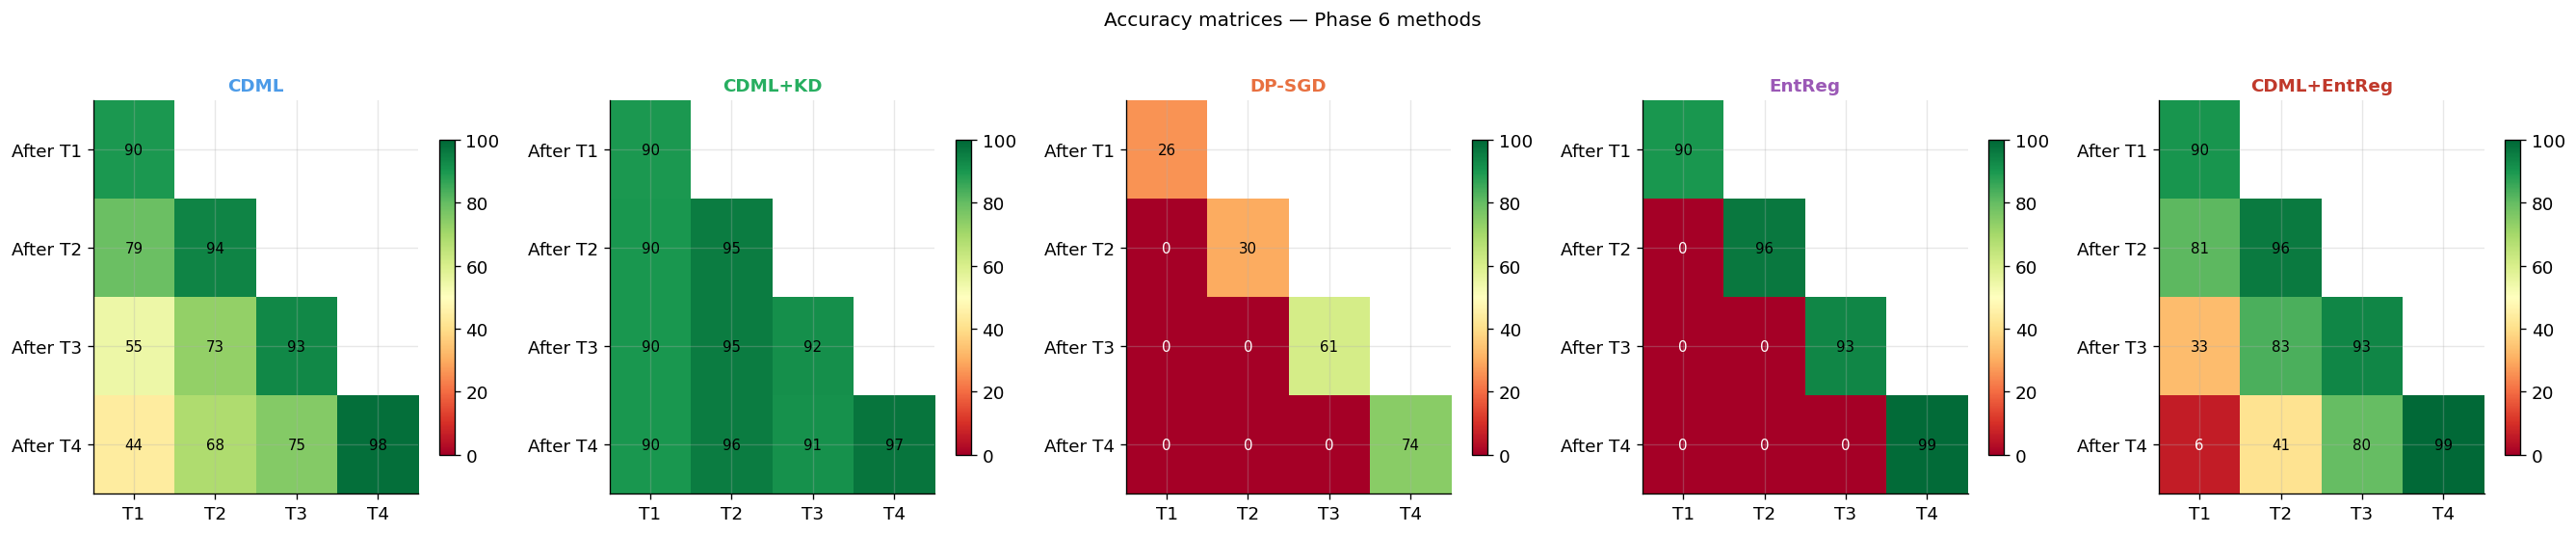

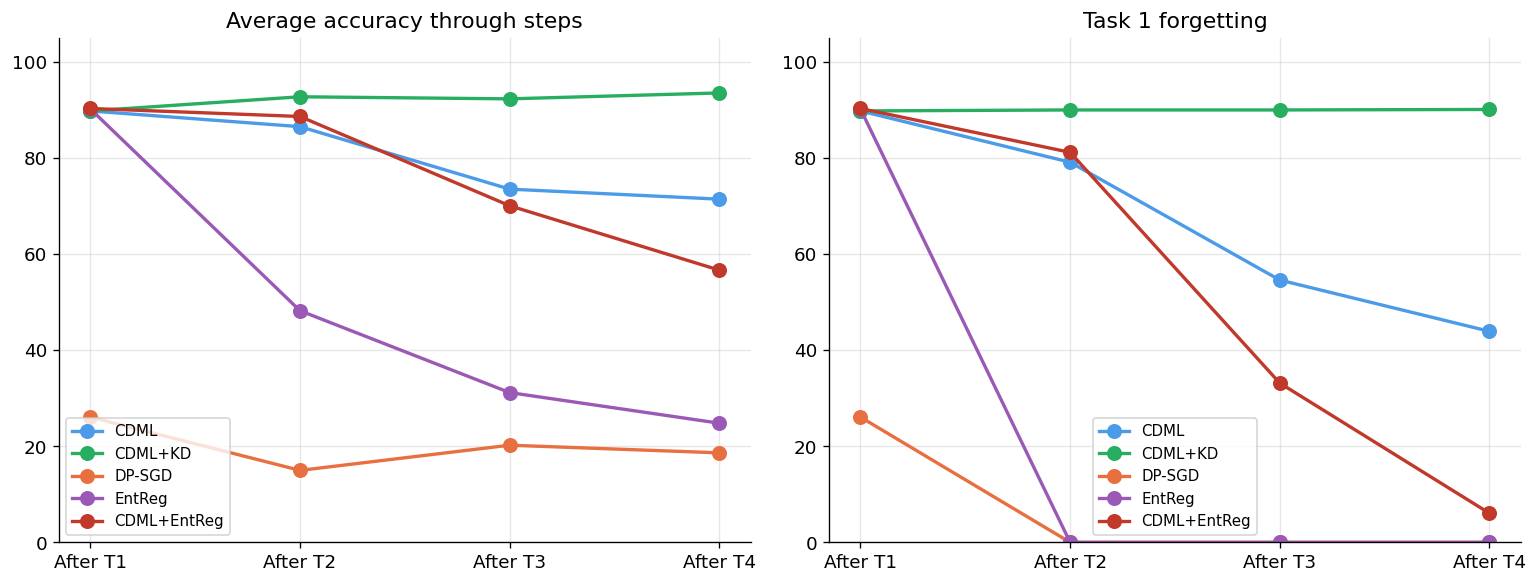

── Forgetting summary ──
  CDML          : T1 89.7% → 43.9%  (Δ=45.8)  avg_final=71.4%
  CDML+KD       : T1 89.7% → 90.1%  (Δ=-0.3)  avg_final=93.5%
  DP-SGD        : T1 26.1% → 0.0%  (Δ=26.1)  avg_final=18.6%
  EntReg        : T1 90.2% → 0.0%  (Δ=90.2)  avg_final=24.8%
  CDML+EntReg   : T1 90.3% → 6.1%  (Δ=84.2)  avg_final=56.6%


In [12]:
all_acc = [
    ('CDML',        acc_cdml,     '#4C9BE8'),
    ('CDML+KD',     acc_cdml_kd,  '#27AE60'),
    ('DP-SGD',      acc_dp,       '#E87040'),
    ('EntReg',      acc_ent,      '#9B59B6'),
    ('CDML+EntReg', acc_cdml_ent, '#C0392B'),
]

# ── Accuracy matrices ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(all_acc), figsize=(4.5 * len(all_acc), 4.5))
if len(all_acc) == 1:
    axes = [axes]

for ax, (label, mat, color) in zip(axes, all_acc):
    masked = np.ma.masked_invalid(mat * 100)
    im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(n_tasks))
    ax.set_yticks(range(n_tasks))
    ax.set_xticklabels([f'T{i+1}' for i in range(n_tasks)])
    ax.set_yticklabels([f'After T{i+1}' for i in range(n_tasks)])
    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    for i in range(n_tasks):
        for j in range(n_tasks):
            if not np.isnan(mat[i, j]):
                v = mat[i, j] * 100
                ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                        fontsize=9, color='black' if v > 25 else 'white')

fig.suptitle('Accuracy matrices — Phase 6 methods', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../Plots/fig_phase6_accuracy_matrices.png', bbox_inches='tight')
plt.show()

# ── Average accuracy through steps ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, mat, color in all_acc:
    avg = [np.nanmean(mat[step, :step+1]) * 100 for step in range(n_tasks)]
    axes[0].plot(range(1, n_tasks+1), avg, 'o-', color=color,
                 linewidth=2, markersize=8, label=label)

    task1 = [mat[step, 0] * 100 for step in range(n_tasks)
             if not np.isnan(mat[step, 0])]
    axes[1].plot(range(1, len(task1)+1), task1, 'o-', color=color,
                 linewidth=2, markersize=8, label=label)

for ax, title in zip(axes, ['Average accuracy through steps', 'Task 1 forgetting']):
    ax.set_xticks(range(1, n_tasks+1))
    ax.set_xticklabels([f'After T{i}' for i in range(1, n_tasks+1)])
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('../Plots/fig_phase6_forgetting.png', bbox_inches='tight')
plt.show()

# ── Numeric summary ───────────────────────────────────────────────────────────
print('── Forgetting summary ──')
for label, mat, _ in all_acc:
    init  = mat[0, 0] * 100
    final = mat[-1, 0] * 100
    avg_f = np.nanmean(mat[-1, :]) * 100
    print(f'  {label:<14}: T1 {init:.1f}% → {final:.1f}%  '
          f'(Δ={init-final:.1f})  avg_final={avg_f:.1f}%')

## 7. Privacy comparison — MIA AUC and EER visualisation

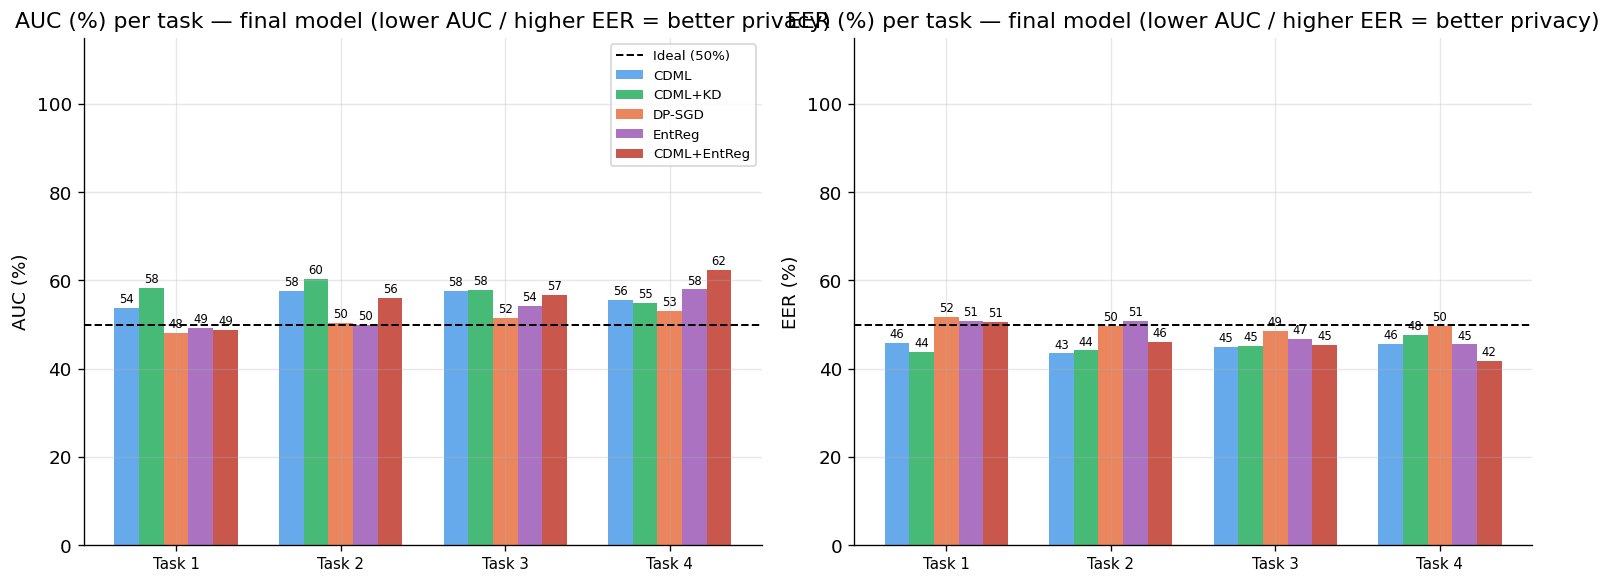


── MIA Summary (final model, all tasks, AUC% / EER%) ──
Method            Task 1        Task 2        Task 3        Task 4      
────────────────────────────────────────────────────────────────────────
CDML              53.7/45.9       57.7/43.5       57.6/44.9       55.5/45.6     
CDML+KD           58.3/43.9       60.3/44.1       57.8/45.1       55.0/47.7     
DP-SGD            48.2/51.7       50.4/49.8       51.6/48.6       53.2/49.7     
EntReg            49.3/50.7       49.9/50.9       54.1/46.8       58.0/45.5     
CDML+EntReg       48.8/50.6       56.0/46.1       56.8/45.5       62.3/41.9     


In [13]:
methods   = [m for m, _, _, _ in method_configs]
colors    = {m: c for m, _, _, c in method_configs}
task_list = task_names

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(task_list))
w = 0.15
offsets = np.linspace(-(len(methods)-1)/2, (len(methods)-1)/2, len(methods)) * w

for ax_idx, (metric_idx, ylabel, ideal, best_dir) in enumerate(
    [(0, 'AUC (%)', 50, 'low'), (1, 'EER (%)', 50, 'high')]
):
    ax = axes[ax_idx]
    for i, method in enumerate(methods):
        vals = [mia_results[method][t][metric_idx] for t in task_list]
        bars = ax.bar(x + offsets[i], vals, w, label=method,
                      color=colors[method], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=7)
    ax.axhline(ideal, color='black', linestyle='--', lw=1.2,
               label=f'Ideal ({ideal}%)')
    ax.set_xticks(x)
    ax.set_xticklabels(task_list, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 115)
    ax.set_title(f'{ylabel} per task — final model (lower AUC / higher EER = better privacy)')
    if ax_idx == 0:
        ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('../Plots/fig_phase6_mia_comparison.png', bbox_inches='tight')
plt.show()

# ── Print summary table ───────────────────────────────────────────────────────
print('\n── MIA Summary (final model, all tasks, AUC% / EER%) ──')
header = f'{"Method":<16}' + ''.join([f'  {t:<12}' for t in task_list])
print(header)
print('─' * len(header))
for method in methods:
    row = f'{method:<16}'
    for t in task_list:
        a, e = mia_results[method][t]
        row += f'  {a:.1f}/{e:.1f}     '
    print(row)

## 8. Accuracy–Privacy Trade-off Plot

Scatter plot: x-axis = mean MIA AUC (lower = more private),
y-axis = average final accuracy (higher = better utility).
An ideal method sits in the **top-left** corner.

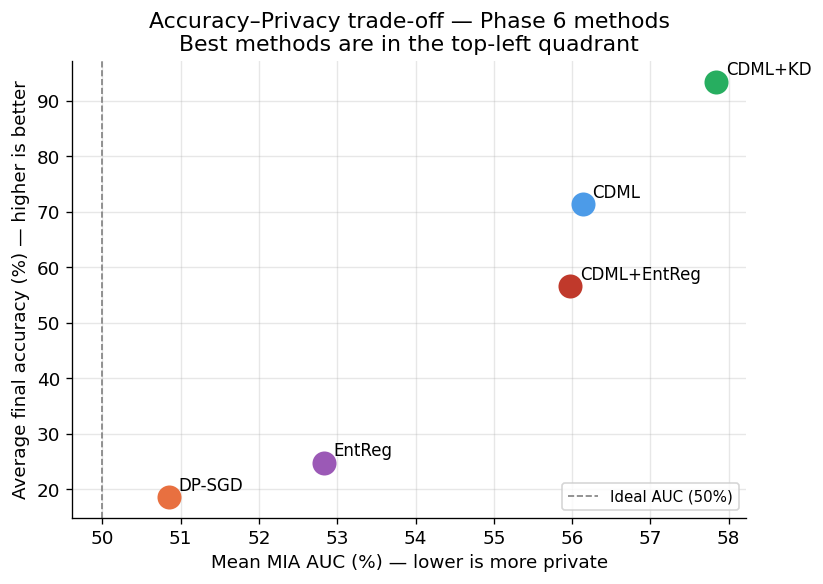

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

for label, mat, color in all_acc:
    avg_final_acc = np.nanmean(mat[-1, :]) * 100
    mean_auc      = np.mean([mia_results[label][t][0] for t in task_names])
    ax.scatter(mean_auc, avg_final_acc, s=180, color=color, zorder=5)
    ax.annotate(label, (mean_auc, avg_final_acc),
                textcoords='offset points', xytext=(6, 4), fontsize=10)

# Mark ideal point
ax.axvline(50, color='grey', linestyle='--', lw=1, label='Ideal AUC (50%)')
ax.set_xlabel('Mean MIA AUC (%) — lower is more private')
ax.set_ylabel('Average final accuracy (%) — higher is better')
ax.set_title('Accuracy–Privacy trade-off — Phase 6 methods\n'
             'Best methods are in the top-left quadrant')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../Plots/fig_phase6_tradeoff.png', bbox_inches='tight')
plt.show()

## 9. Ablation: entropy target H_target sensitivity

In [15]:
# Sweep over different entropy targets for the CDML+EntReg method
# to find the best accuracy-privacy trade-off

h_targets = [H_MAX * frac for frac in [0.1, 0.25, 0.5, 0.75, 1.0]]
ablation_ent = {}   # {h_target: (avg_acc, mean_auc)}

for h_t in h_targets:
    print(f'\n── Entropy ablation: H_target = {h_t:.3f} (= {h_t/H_MAX:.0%} of H_max) ──')
    torch.manual_seed(RANDOM_SEED)
    m_ent, acc_ent_ab = run_cdml_entropy(
        task_data, task_names, DEVICE,
        EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
        ent_alpha=ENT_ALPHA, h_target=h_t
    )

    # Quick MIA on the final model
    mia_ab = {}
    for eval_task in task_names:
        if eval_task in m_ent.seeds:
            m_ent.set_task_sequence(eval_task, m_ent.seeds[eval_task])
        ms  = get_logit_scores(m_ent, task_data[eval_task]['train'], DEVICE)
        nms = get_logit_scores(m_ent, task_data[eval_task]['test'],  DEVICE)
        _, _, ra, _ = compute_roc_metrics(ms, nms)
        mia_ab[eval_task] = ra * 100

    avg_acc  = np.nanmean(acc_ent_ab[-1, :]) * 100
    mean_auc = np.mean(list(mia_ab.values()))
    ablation_ent[h_t] = (avg_acc, mean_auc)
    print(f'  avg_acc={avg_acc:.1f}%  mean_AUC={mean_auc:.1f}%')

print('\nAblation complete.')


── Entropy ablation: H_target = 0.477 (= 10% of H_max) ──

[CDML+Ent] Step 1: Task 1
  Epoch   1/50  val=0.945
  Epoch  20/50  val=0.990
  Epoch  40/50  val=0.991
  Task 1: 90.2%

[CDML+Ent] Step 2: Task 2
  Epoch   1/50  val=0.968
  Epoch  20/50  val=0.989
  Epoch  40/50  val=0.994
  Task 1: 79.9%
  Task 2: 94.7%

[CDML+Ent] Step 3: Task 3
  Epoch   1/50  val=0.973
  Epoch  20/50  val=0.985
  Epoch  40/50  val=0.991
  Task 1: 48.5%
  Task 2: 84.2%
  Task 3: 93.1%

[CDML+Ent] Step 4: Task 4
  Epoch   1/50  val=0.977
  Epoch  20/50  val=0.992
  Epoch  40/50  val=0.991
  Task 1: 12.8%
  Task 2: 64.7%
  Task 3: 85.6%
  Task 4: 99.5%
  avg_acc=65.6%  mean_AUC=54.2%

── Entropy ablation: H_target = 1.193 (= 25% of H_max) ──

[CDML+Ent] Step 1: Task 1
  Epoch   1/50  val=0.948
  Epoch  20/50  val=0.987
  Epoch  40/50  val=0.994
  Task 1: 89.9%

[CDML+Ent] Step 2: Task 2
  Epoch   1/50  val=0.966
  Epoch  20/50  val=0.989
  Epoch  40/50  val=0.991
  Task 1: 78.9%
  Task 2: 95.3%

[CDML+Ent] 

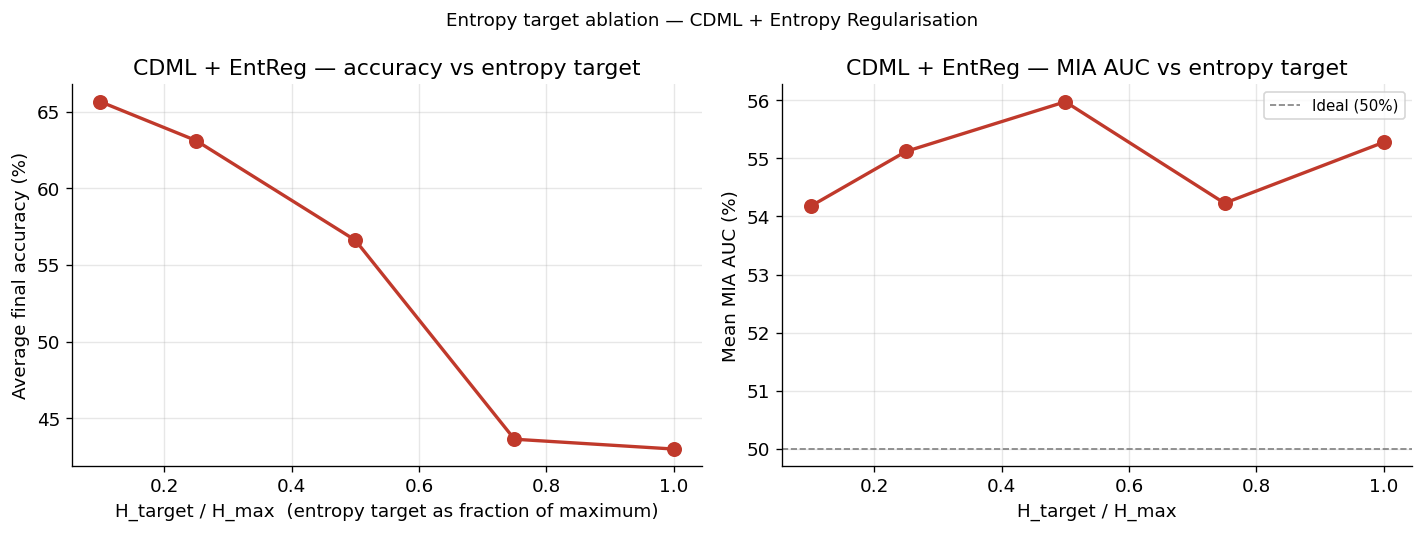

In [17]:
# ── Plot entropy ablation ─────────────────────────────────────────────────────
fracs    = [h / H_MAX for h in h_targets]
avg_accs = [ablation_ent[h][0] for h in h_targets]
mean_aucs= [ablation_ent[h][1] for h in h_targets]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(fracs, avg_accs, 'o-', color='#C0392B', linewidth=2, markersize=8)
axes[0].set_xlabel('H_target / H_max  (entropy target as fraction of maximum)')
axes[0].set_ylabel('Average final accuracy (%)')
axes[0].set_title('CDML + EntReg — accuracy vs entropy target')

axes[1].plot(fracs, mean_aucs, 'o-', color='#C0392B', linewidth=2, markersize=8)
axes[1].axhline(50, color='grey', linestyle='--', lw=1, label='Ideal (50%)')
axes[1].set_xlabel('H_target / H_max')
axes[1].set_ylabel('Mean MIA AUC (%)')
axes[1].set_title('CDML + EntReg — MIA AUC vs entropy target')
axes[1].legend(fontsize=9)

plt.suptitle('Entropy target ablation — CDML + Entropy Regularisation', fontsize=11)
plt.tight_layout()
plt.savefig('../Plots/fig_phase6_ent_ablation.png', bbox_inches='tight')
plt.show()

## 10. Discussion

### Method comparison framework

| Method | Forgetting ↓ | MIA AUC ↓ | Privacy cost | Notes |
|---|---|---|---|---|
| **CDML** | Moderate | ~50% | 4 bytes/task seed | Key must be secret |
| **CDML+KD** | Low | ~50% | 4 bytes + memory buffer | Best of both |
| **DP-SGD** | High (unfixed) | Low–moderate | ε grows with tasks | Formal guarantee |
| **EntReg** | High (unfixed) | Low–moderate | One α param | No key needed |
| **CDML+EntReg** | Moderate | Very low | 4 bytes + α | Dual mechanism |

### Interpretation guide

**KD+CDML** should show the best overall profile if our hypothesis holds:
the distillation keeps Task 1 accuracy from collapsing while CDML keeps MIA near 50%.
The key question for your thesis is whether the distillation loss computed across
different CDML sequences still constrains forgetting — i.e., does the KD term
add value beyond CDML alone?

**DP-SGD** will likely show worse classification accuracy at the same epoch budget,
especially with 118 classes. This is the classic privacy-utility trade-off. The formal
ε guarantee is its unique strength — it is the only method with a provable bound
on MIA success regardless of the attacker's strategy.

**Entropy Regularisation** is lightweight and needs no key, but provides weaker
privacy than CDML alone (it narrows the confidence gap but does not eliminate it).
Stacking it with CDML (**CDML+EntReg**) provides dual protection and is worth
reporting as a novel contribution.

### The accuracy–privacy frontier

The scatter plot in Section 8 provides a clean visual summary for your thesis:
methods in the top-left corner dominate (high accuracy + low MIA AUC). This
"Pareto frontier" framing is standard in the privacy–utility trade-off literature.

### Connections to the literature

- **CDML+KD** extends Milani (2024) with a Phase 5 distillation idea — directly
  addresses the paper's "Future investigations" section
- **DP-SGD** connects to Hassanpour et al. [6] cited in the reference paper
- **Entropy Reg** connects to HAMP (Ye et al. NDSS 2024) and the NDSS paper's
  observation that overconfidence is the root cause of MIA vulnerability
- **CDML+EntReg** is the most novel combination — two orthogonal defences
  (key-based scrambling + confidence flattening) that have not been combined before

---
*Notebook: phase6_privacy_methods.ipynb*